In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline
import numpy as np

In [18]:
sequences = np.load("CMdata.npz")["seqs"]

min_len = 75
max_len = 95
filtered_sequences = [s for s in sequences if min_len <= len(s) <= max_len]
sequences = filtered_sequences
len(sequences)

8727

In [19]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(sequences))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'A', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'K', 10: 'L', 11: 'M', 12: 'N', 13: 'P', 14: 'Q', 15: 'R', 16: 'S', 17: 'T', 18: 'V', 19: 'W', 20: 'Y', 0: '.'}
21


In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [21]:
# build the dataset
block_size = 70 # context length: how many characters do we take to predict the next one?

def build_dataset(sequences):
  X, Y = [], []

  for w in sequences:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(sequences)
#n1 = int(0.8*len(sequences))
n2 = int(0.9*len(sequences))

Xtr,  Ytr  = build_dataset(sequences[:n2])    # 90%
Xdev, Ydev = build_dataset(sequences[n2:])   # 10%


Xtr = Xtr.to(device)
Ytr = Ytr.to(device)
Xdev = Xdev.to(device)
Ydev = Ydev.to(device)


torch.Size([634200, 70]) torch.Size([634200])
torch.Size([70531, 70]) torch.Size([70531])


In [22]:
n_embd = 13 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
g = torch.Generator(device=device).manual_seed(1) # for reproducibility

C = torch.randn((vocab_size, n_embd), generator=g, device=device)

layers = [
  nn.Linear(n_embd * block_size, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
  nn.Linear(           n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
  #nn.Linear(           n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
  #nn.Linear(           n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
  #nn.Linear(           n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
  nn.Linear(           n_hidden, vocab_size, bias=False), nn.BatchNorm1d(vocab_size),
]

for layer in layers:
  layer.to(device)

with torch.no_grad():
  # last layer: make less confident
  layers[-1].weight *= 0.1
  #layers[-1].weight *= 0.1
  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, nn.Linear):
      layer.weight *= 1

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

import torch.optim as optim

optimizer = optim.Adam(parameters, lr=1e-4)  # Initial LR
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=150000, gamma=0.1)

227315


In [23]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

#we expect around 3, if the initialization is good the probability given to the good token is 1/20 that is e-3

train 3.051438331604004
val 3.051259994506836


In [24]:
g = torch.Generator(device=device).manual_seed(1) # for reproducibility
max_steps = 90001
batch_size = 256
lossi = []
ud = []

lri = (torch.logspace(-4,0,max_steps))


for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g, device = device)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function

  # backward pass
  #optimizer.zero_grad()

  for p in parameters:
    p.grad = None
  loss.backward()


  # update
  #optimizer.step()
  #scheduler.step()

  lr = 0.01 if i < 60000 else 0.001 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print('epoch    ',f'{i}')
    split_loss('val')
    split_loss('train')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  #if i >= 10000:
   # break # AFTER_DEBUG: would take out obviously to run full optimization
  

# --- Saving ---

# Saving
save_dict = {'C': C.cpu(), 'layers': [layer.state_dict() for layer in layers]}
torch.save(save_dict, f'nn_parameters_{batch_size}_noss.pt')


epoch     0
val 3.050548553466797
train 3.0507161617279053
epoch     10000
val 1.314384937286377
train 1.1970467567443848
epoch     20000
val 1.2273321151733398
train 1.0603904724121094
epoch     30000
val 1.2040282487869263
train 0.995910108089447
epoch     40000
val 1.1900734901428223
train 0.943498432636261
epoch     50000
val 1.1898012161254883
train 0.9102118611335754
epoch     60000
val 1.180916428565979
train 0.8741397857666016
epoch     70000
val 1.1586836576461792
train 0.8181774616241455
epoch     80000
val 1.1623562574386597
train 0.8095434904098511
epoch     90000
val 1.1660990715026855
train 0.803708553314209


In [25]:
# --- Loading ---
# Loading a trained model
# Loading
with torch.no_grad():
    loaded = torch.load(f'nn_parameters_256_noss.pt', map_location=device)
    C.copy_(loaded['C'].to(device))
    for layer, state in zip(layers, loaded['layers']):
        layer.load_state_dict(state)

/var/folders/4w/gzvp177j2y16550mg65xsbjc0000gn/T/ipykernel_89483/3623384874.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(f'nn_parameters_256_noss.

In [26]:
split_loss('train')
split_loss('val')

train 0.803708553314209
val 1.1660990715026855


layer 2 (      Tanh): mean +0.00, std 0.65, saturated: 6.84%
layer 5 (      Tanh): mean -0.00, std 0.66, saturated: 6.37%


Text(0.5, 1.0, 'activation distribution')

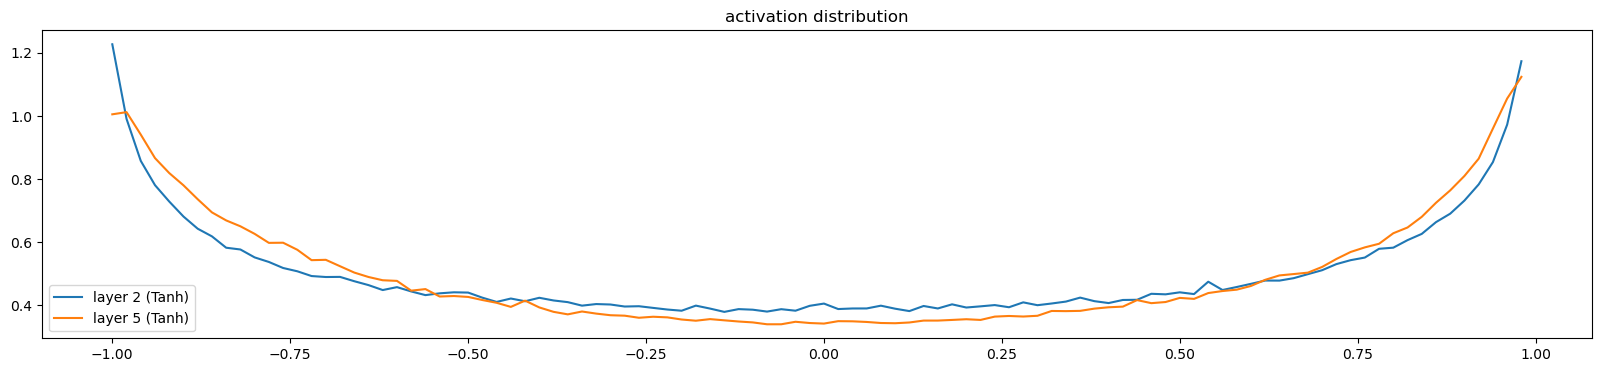

In [27]:
# visualize histograms

emb = C[Xdev] # embed the characters into vectors
x = emb.view(emb.shape[0], -1)


activations = []

for i, layer in enumerate(layers):
    x = layer(x)
    if isinstance(layer, nn.Tanh):  # or nn.ReLU, nn.LeakyReLU, etc.
        activations.append((i, layer.__class__.__name__, x.detach().cpu().view(-1)))

# Plotting
plt.figure(figsize=(20, 4))
legends = []

for i, name, t in activations:
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' %
          (i, name, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, bins=100, density=True)
    plt.plot(hx[:-1], hy)
    legends.append(f'layer {i} ({name})')

plt.legend(legends)
plt.title('activation distribution')


layer 2 (      Tanh): grad mean +0.00, std 0.00, saturated: 0.00%
layer 5 (      Tanh): grad mean +0.00, std 0.00, saturated: 0.00%


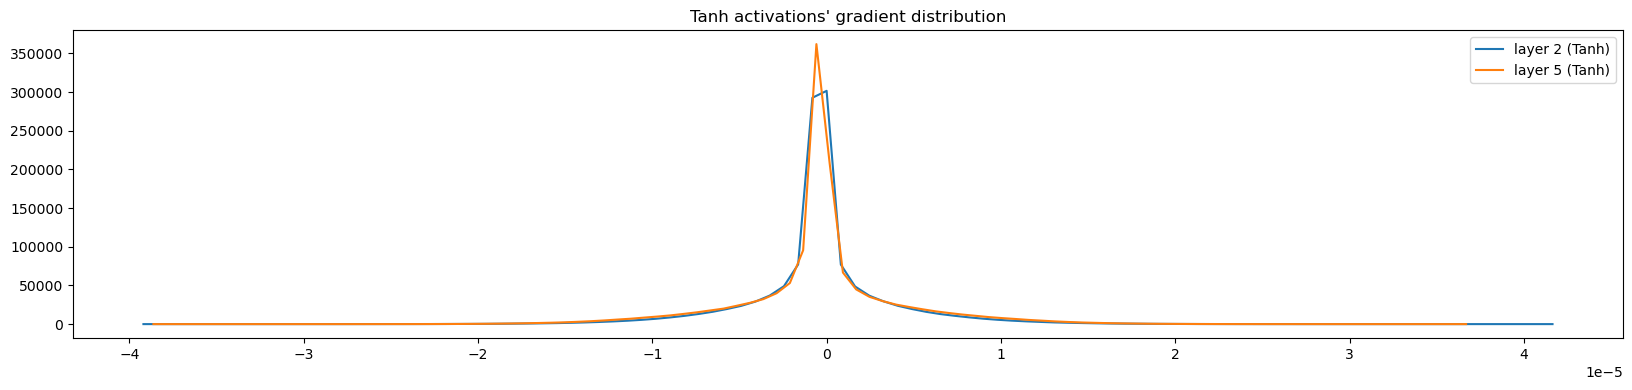

In [28]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Example dummy input
emb = C[Xdev]  # Embedding step
x = emb.view(emb.shape[0], -1)  # Flatten

activations = []

# Forward pass and retain gradients for Tanh outputs
for i, layer in enumerate(layers):
    x = layer(x)
    if isinstance(layer, nn.Tanh):
        x.retain_grad()  # <-- retain gradient for this activation
        activations.append((i, layer.__class__.__name__, x))

# Compute loss and backward
logits = x  # Assume last x is model output
loss = F.cross_entropy(logits, Ydev)  # Assume Ydev is your target
loss.backward()

# Plotting gradients of Tanh activations
plt.figure(figsize=(20, 4))
legends = []

for i, name, act in activations:
    g = act.grad  # now it should exist
    if g is None:
        continue
    g = g.detach().cpu().view(-1)
    print('layer %d (%10s): grad mean %+.2f, std %.2f, saturated: %.2f%%' %
          (i, name, g.mean(), g.std(), (g.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(g, bins=100, density=True)
    plt.plot(hx[:-1], hy)
    legends.append(f'layer {i} ({name})')

plt.legend(legends)
plt.title("Tanh activations' gradient distribution")
plt.show()

weight   (21, 13) | mean +0.000000 | std 7.288015e-03 | grad:data ratio 7.071421e-03
weight (200, 910) | mean -0.000029 | std 9.730631e-03 | grad:data ratio 3.344281e-01
weight (200, 200) | mean -0.000050 | std 1.602341e-02 | grad:data ratio 3.011761e-01
weight  (21, 200) | mean +0.000310 | std 2.754043e-02 | grad:data ratio 3.354741e-01


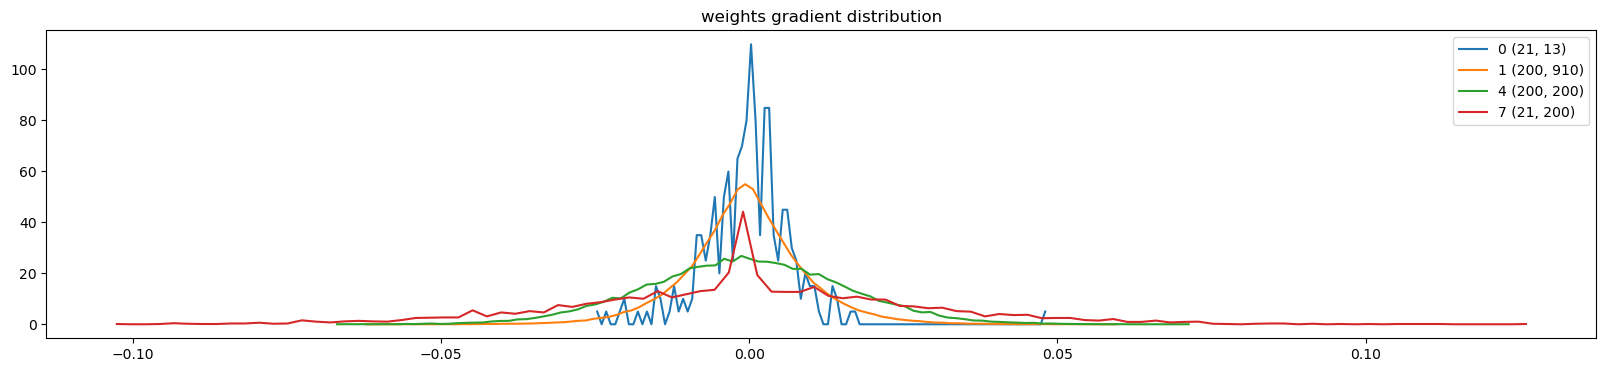

In [29]:
plt.figure(figsize=(20, 4))
legends = []

for i, p in enumerate(parameters):
    t = p.grad
    if t is None:
        continue  # skip if grad is None (e.g., frozen layers)

    if p.ndim == 2:
        t = t.detach().cpu().view(-1)  # flatten & move to CPU
        param_std = p.std().detach().cpu()
        grad_std = t.std()
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' %
              (tuple(p.shape), t.mean(), grad_std, grad_std / param_std))

        hy, hx = torch.histogram(t, bins=100, density=True)
        plt.plot(hx[:-1].cpu(), hy.cpu())  # ensure plotting from CPU
        legends.append(f'{i} {tuple(p.shape)}')

plt.legend(legends)
plt.title('weights gradient distribution')
plt.show()


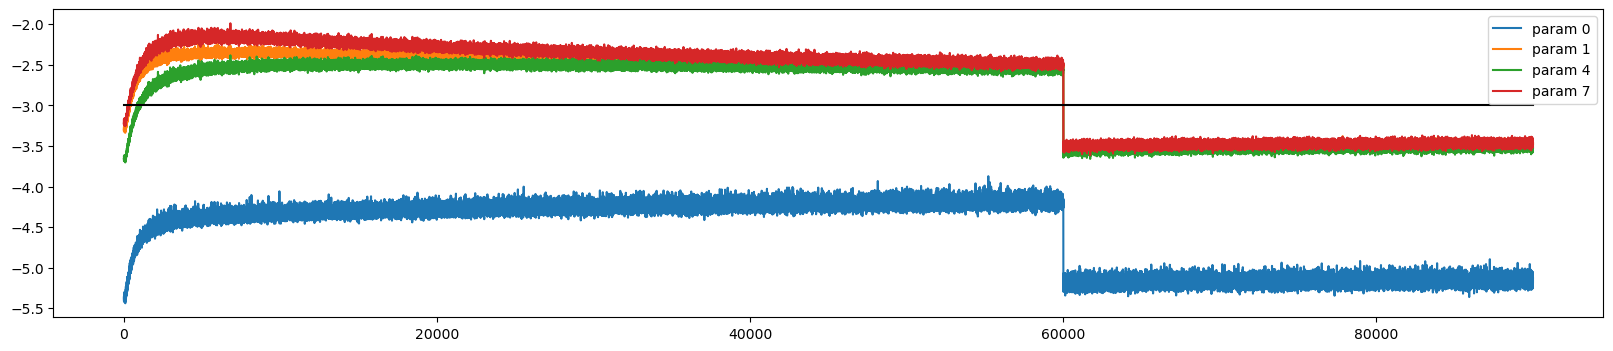

In [30]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
 if p.ndim == 2:
   plt.plot([ud[j][i] for j in range(len(ud))])
   legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

In [31]:
g = torch.Generator(device=device).manual_seed(0)
n = 1000

for layer in layers:
    layer.eval()

with open('generated_sequences_noss.txt', 'w') as f:
    for _ in range(n):
        out = []
        context = [0] * block_size  # initialize with all ...
        while True:
            emb = C[torch.tensor([context])]  # (1, block_size, n_embd)
            x = emb.view(emb.shape[0], -1)  # flatten
            for layer in layers:
                x = layer(x)
            logits = x
            probs = F.softmax(logits, dim=1)
            ix = torch.multinomial(probs, num_samples=1, generator=g).item()
            context = context[1:] + [ix]
            out.append(ix)
            if ix == 0:  # special token
                break

        sequence = ''.join(itos[i][0] for i in out[0:-1])
        header = f'>seq_{_}'
        #print(header)
        #print(sequence)
        f.write(header + '\n')
        f.write(sequence + '\n')

In [ ]:
# def get_odd_lines(file_path):
#     odd_lines = []
#     with open(file_path, 'r') as file:
#         for index, line in enumerate(file, start=1):
#             if index % 2 == 0:
#                 odd_lines.append(line.rstrip('\n'))
#     return odd_lines


# seq_devi = get_odd_lines('OriginalData/russEtal-align.fasta')
# seq_dev = [s + '.' for s in seq_devi]  # Add a stop character to the end of each sequence

In [32]:
### Outils for measuring energy structures on DEV set


def create_vector(n):
    if not (0 <= n < 21):
        raise ValueError("Input must be between 0 and 40 inclusive.")

    vec = [0] * 21
    vec[n] = 1  # Set the nth position to 1

    return vec


In [33]:
seq_devi = get_odd_lines('OriginalData/russEtal-align.fasta')
seq_dev = [s + '.' for s in seq_devi]  # Add a stop character to the end of each sequence


for layer in layers:
    layer.eval()

    
with open('energy_DEV.txt', 'w') as f:
    for _ in range(len(seq_dev)):
        out = []
        context = [0] * block_size  # initialize with all ...
        probss = []
        sqi = 0
        while sqi < len(seq_dev[_]):
            emb = C[torch.tensor([context])]  # (1, block_size, n_embd)
            x = emb.view(emb.shape[0], -1)  # flatten
            
            for layer in layers:
                x = layer(x)
            logits = x

            temp = [stoi[seq_dev[_][sqi]] for i in range(len(seq_dev[_]))]
            mask = create_vector(temp[sqi])
            probs = F.softmax(logits, dim=1) * torch.tensor(mask, device=device)

            prob = torch.sum(probs)  # (1, vocab_size)
            #prob = torch.max(probs)
            ix = torch.argmax(probs).item() # autoregressive maximum structure token

            context = context[1:] + [ix]
            probss.append(prob.item())
            out.append(ix)
            sqi += 1
            if ix == 0:  # special token
                #print(out)
                break

        sequence = ''.join(itos[i][0] for i in out[0:-1])
        #structure = ''.join(itos[i][1] for i in out[0:-1])
        header = f'>DEV_seq_{_}'
        #print(header)
        #print(sequence)
        f.write(header + '\n')
        f.write(sequence + '\n')
        #f.write(structure + '  predicted_one\n')
        print(len(probss))
        f.write(str((-torch.tensor(probss).log()).mean().item()))  # write the log probability of the predicted structure
        f.write('\n')
       # f.write(struct_dev[_][0:-1] + '  true_one\n')

80
81
79
80
80
81
80
80
80
77
81
80
79
76
80
80
80
79
79
80
81
80
76
78
80
80
80
81
70
78
80
69
77
80
80
80
80
79
80
80
80
80
76
81
80
79
79
81
80
80
79
80
79
80
79
80
81
80
80
81
79
80
18
80
80
71
81
70
81
78
2
74
80
81
79
80
80
2
78
80
70
70
78
21
81
81
81
80
80
81
80
79
79
81
81
80
79
79
80
80
79
80
80
81
80
80
81
77
80
80
79
79
80
80
76
80
78
79
71
5
79
80
80
79
81
79
79
77
80
80
80
76
81
80
81
80
80
69
80
81
81
80
80
81
80
79
80
70
80
77
56
79
13
79
79
77
80
77
79
80
81
77
80
80
80
80
80
79
81
80
79
79
81
80
80
80
80
76
80
81
81
79
78
79
80
80
70
69
80
80
80
78
80
80
79
81
80
80
81
77
79
70
81
79
80
80
81
80
80
79
81
80
76
80
2
79
80
80
76
80
81
80
80
80
79
80
79
78
79
80
78
68
79
80
79
78
80
80
79
81
80
81
79
80
80
81
80
79
81
79
80
80
80
77
80
81
79
79
79
80
80
78
76
16
80
79
78
80
79
80
80
23
81
79
78
80
79
79
79
78
77
81
80
79
80
80
80
81
80
79
80
80
80
78
80
80
80
80
2
81
80
80
14
80
79
81
78
77
78
79
75
80
81
80
80
16
15
80
81
76
77
81
80
79
81
80
81
79
79
79
80
80
72
80
80


<BarContainer object of 13 artists>

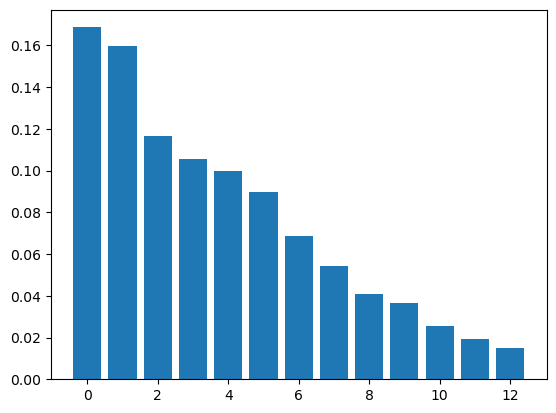

In [34]:
# Analyzing the embedding (first two PCA)

import sklearn
from sklearn.decomposition import PCA
import numpy as np

# Example data: rows = samples, columns = features
X = np.random.rand(100, 50)  # 100 samples, 50 features

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=13)
C_pca = pca.fit_transform(C.detach().numpy())
plt.bar(range(13), pca.explained_variance_ratio_)

In [35]:
affinity = [
    "black",   # ..
    "red",     # A
    "red",     # C
    "blue",    # D
    "blue",    # E
    "red",     # F
    "yellow",  # G
    "yellow",  # H
    "red",     # I
    "blue",    # K
    "red",     # L
    "red",     # M
    "blue",    # N
    "yellow",  # P
    "blue",    # Q
    "blue",    # R
    "yellow",  # S
    "yellow",  # T
    "red",     # V
    "red",     # W
    "yellow"   # Y
]

size = [
    "black",   # ..
    "blue",    # A
    "blue",    # C
    "blue",    # D
    "yellow",  # E
    "red",     # F
    "blue",    # G
    "yellow",  # H
    "red",     # I
    "red",     # K
    "red",     # L
    "red",     # M
    "blue",    # N
    "blue",    # P
    "yellow",  # Q
    "red",     # R
    "blue",    # S
    "blue",    # T
    "yellow",  # V
    "red",     # W
    "red"      # Y
]

charge = [
    "black",   # ..
    "yellow",  # A
    "yellow",  # C
    "blue",    # D
    "blue",    # E
    "yellow",  # F
    "yellow",  # G
    "red",     # H
    "yellow",  # I
    "red",     # K
    "yellow",  # L
    "yellow",  # M
    "yellow",  # N
    "yellow",  # P
    "yellow",  # Q
    "red",     # R
    "yellow",  # S
    "yellow",  # T
    "yellow",  # V
    "yellow",  # W
    "yellow"   # Y
]

polarity = [
    "black",   # ..
    "yellow",  # A
    "yellow",  # C
    "blue",    # D
    "blue",    # E
    "yellow",  # F
    "yellow",  # G
    "blue",    # H
    "yellow",  # I
    "blue",    # K
    "yellow",  # L
    "yellow",  # M
    "blue",    # N
    "yellow",  # P
    "blue",    # Q
    "blue",    # R
    "blue",    # S
    "blue",    # T
    "yellow",  # V
    "yellow",  # W
    "blue"     # Y
]

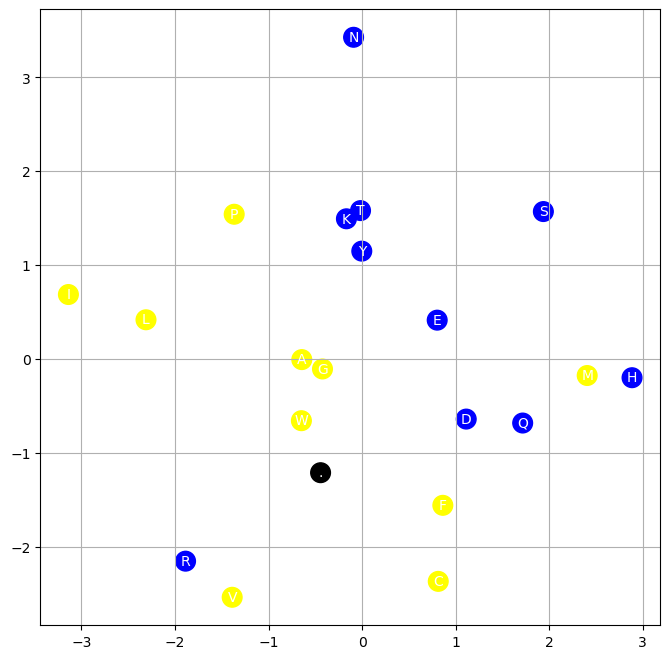

In [40]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C_pca[:,0].data, C_pca[:,1].data, s=200, c = polarity)
for i in range(C_pca.shape[0]):
    plt.text(C_pca[i,0].item(), C_pca[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')